# **AI-Enhanced Customer Support Application with Chatbot Integration -**
# **Agentic Banking Assistant**

## Objectives





* Understand how Agentic AI can automate core banking operations
* Design tool-based systems for LLM interaction with structured data
* Build agents that interpret user queries and invoke appropriate tools
* Develop orchestration workflows between agents, tools, and databases
* Implement secure transaction handling with basic validations
* Generate structured outputs such as mini statements
* Handle filtered queries like debit/credit transaction views
* Add post-processing guardrail
* Test and validate the system using real-world scenarios


## Problem Statement

Banks and financial institutions handle a large volume of customer requests related to account information, transactions, and fund transfers. These interactions are often initiated through chat, mobile apps, or support channels and involve repetitive yet critical operations.

Currently, many banking support processes are **manual, fragmented, and query-driven**, leading to several challenges:

* **Delayed response times** for customer requests
* **Inconsistent handling** of similar queries across channels
* **Over-reliance on human intervention** for routine operations
* **Limited ability to process natural language queries efficiently**
* **Lack of seamless integration** between user interactions and backend systems

A significant portion of customer requests typically falls into the following categories:

* **Information retrieval**, such as checking account balance or viewing transactions
* **Transaction operations**, such as transferring funds between accounts
* **Filtered queries**, such as viewing only debit or credit transactions
* **Statement generation**, such as requesting a mini statement of recent activities

However, most existing systems lack the capability to:

* Automatically **understand and interpret user queries from natural language inputs**
* Dynamically **select and execute appropriate backend operations (tools)**
* Provide **consistent, accurate, and real-time responses**
* Seamlessly **integrate conversational AI with structured banking data**

*The goal is to design and develop an **AI-Based Agentic Banking System** that can:*

* Interpret user queries and map them to appropriate banking operations
* Enable intelligent agents to interact with tools for balance checks, transactions, and transfers
* Support filtered views of transaction data (debit/credit)
* Generate structured outputs such as mini statements
* Provide a unified, automated, and efficient banking assistance experience


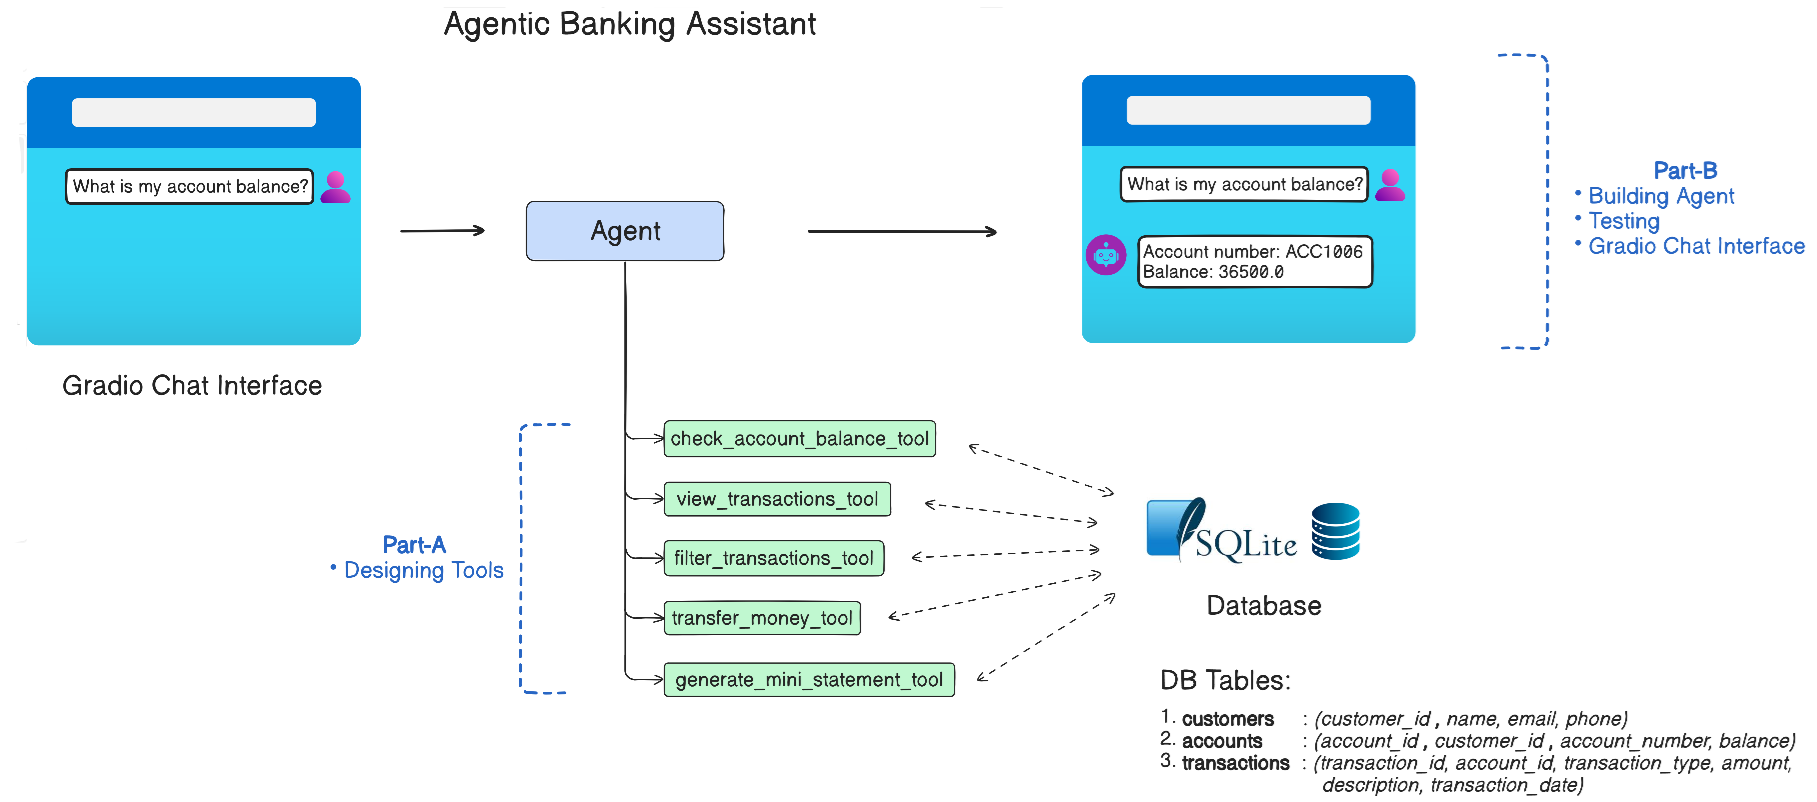

## Database Tables

Design a structured database to support all banking operations and tool interactions.

* ***customers***

  Stores basic customer details such as customer ID, name, and contact information (email).

* ***accounts***

  Maintains account-specific data including account ID, linked customer ID, and current balance.

* ***transactions***

  Records all debit and credit transactions with details like transaction ID, account ID, amount, type, and timestamp.

These tables enable efficient data retrieval, transaction processing, and support all agent-driven banking functionalities.


## Sample Input Queries to Test the System




1. Check Balance

    * *What is my current balance?*
    * *Show my account balance*
    * *How much money do I have in my account?*

---

2. See Transactions

    * *Show my recent transactions*
    * *Display last 10 transactions*
    * *Give me my transaction history*

---

3. Filter Debit/Credit

    * *Show only debit transactions*
    * *Show only credit transactions*
    * *List all my debit entries*
    * *Display my credit transactions*

---

4. Transfer Amount

    * *Transfer ₹2000 to ACC1002*
    * *Pay ₹1000 to account number ACC1002*

---

5. Mini Statement

    * *Generate my mini statement*
    * *Show last 5 transactions as a statement*
    * *Give me my mini statement for recent transactions*

---

6. Edge Case / Validation Queries

    * *Transfer ₹1,00,000 to ACC1002 (insufficient balance scenario)*
    * *Send money to an unknown user*
    * *Show transactions for last 2 years*
    * *Transfer money without specifying amount*

---



#    Designing Tools

    1. Design and implement all the necessary backend tools (functions/APIs) required to support banking operations.

    2. This includes creating tools for balance checking, viewing transactions, transferring funds, filtering debit/credit transactions, and generating mini statements.

    3. Ensure that each tool interacts correctly with the underlying database and includes essential validations such as sufficient balance checks and valid beneficiary handling.

    4. The focus is on building reliable, reusable, and well-structured tools that can be invoked by the agent during execution.

#    Building Agent, Testing, & Gradio Implementation

    1. Design and implement the agent orchestration workflow to handle user queries and invoke appropriate tools dynamically.

    2. This includes building an intelligent agent capable of interpreting user intent, selecting the correct tool, managing multi-step operations (such as validation before transfer), and formatting responses.

    3. Also, test the complete system using sample user queries to validate accuracy, correctness, and robustness of the workflow.

    4. Ensure the system handles edge cases such as insufficient balance, invalid inputs, and unsupported queries effectively, providing a smooth and reliable user experience.

---

### Install Required Libraries

In [89]:
%%capture
!pip -q install openai==2.3.0
!pip -q install langchain-core==0.3.79
!pip -q install langchain-community==0.3.31
!pip -q install sentence-transformers==5.1.1
!pip -q install langchain-huggingface==0.3.1
!pip -q install langchain-experimental==0.3.4
!pip -q install langchainhub==0.1.21
!pip -q install langchain-openai==0.3.35
!pip -q install langgraph==0.6.8

### Import Neccesary Packages

In [90]:
import os
import sqlite3
from datetime import datetime
from google.colab import userdata

from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, create_react_agent, tools_condition
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

from typing import TypedDict, List, Optional, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

### Read the Groq API Key

Using the Groq API Key, the access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits) is made use of.

This cell retrieves the Groq API key securely stored in Google Colab's Secrets and sets it as an environment variable `GROQ_API_KEY`.

In [91]:
import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

### Initialize LLM

In [92]:
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",   # Groq-supported model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

### **Create a SQLite Database (in-memory)**

**SQLite** is a C library that provides a lightweight disk-based database that doesn't require a separate server process and allows accessing the database using a nonstandard variant of the SQL query language. Some applications can use SQLite for internal data storage.

SQLite3 specifically refers to the third version of SQLite.

In [93]:
import sqlite3
# --- SQLite DB ---
DB_FILE = "banking_system.db"


def init_db():

    # Create / connect to SQLite database
    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    # Enable foreign key support
    cursor.execute("PRAGMA foreign_keys = ON;")

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS customers (
        customer_id TEXT PRIMARY KEY,
        name TEXT NOT NULL,
        email TEXT,
        phone TEXT
    );
    """)

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS accounts (
        account_id TEXT PRIMARY KEY,
        customer_id TEXT NOT NULL,
        account_number TEXT UNIQUE NOT NULL,
        balance REAL NOT NULL,
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
    );
    """)

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS transactions (
        transaction_id TEXT PRIMARY KEY,
        account_id TEXT NOT NULL,
        transaction_type TEXT NOT NULL CHECK(transaction_type IN ('debit', 'credit')),
        amount REAL NOT NULL,
        description TEXT,
        transaction_timestamp TEXT NOT NULL,
        FOREIGN KEY (account_id) REFERENCES accounts(account_id)
    );
    """)

    # -----------------------------
    # Insert Sample Data
    # -----------------------------

    customers_data = [
        ("C1", "Aarav Sharma", "aarav@example.com", "9876543210"),
        ("C2", "Rahul Verma", "rahul@example.com", "9876501234"),
        ("C3", "Priya Mehta", "priya@example.com", "9876512345"),
        ("C4", "Neha Kapoor", "neha@example.com", "9876523456"),
        ("C5", "Rohan Singh", "rohan@example.com", "9876534567"),
        ("C6", "Ananya Gupta", "ananya@example.com", "9876545678")
    ]

    accounts_data = [
        ("A1", "C1", "ACC1001", 48300.00),
        ("A2", "C2", "ACC1002", 28300.00),
        ("A3", "C3", "ACC1003", 43500.00),
        ("A4", "C4", "ACC1004", 0.00),
        ("A5", "C5", "ACC1005", 55300.00),
        ("A6", "C6", "ACC1006", 36500.00)
    ]

    transactions_data = [
        # Aarav
        ("T1", "A1", "credit", 50000.00, "Salary credited", "2026-05-01 10:00:00"),
        ("T2", "A1", "debit", 2500.00, "Online shopping", "2026-05-02 14:30:00"),
        ("T3", "A1", "debit", 1200.00, "Electricity bill", "2026-05-03 09:15:00"),
        ("T4", "A1", "credit", 5000.00, "Refund received", "2026-05-04 16:45:00"),
        ("T5", "A1", "debit", 3000.00, "Restaurant", "2026-05-05 20:10:00"),

        # Rahul
        ("T6", "A2", "credit", 30000.00, "Salary credited", "2026-05-01 10:10:00"),
        ("T7", "A2", "debit", 1500.00, "Mobile recharge", "2026-05-03 12:00:00"),
        ("T8", "A2", "debit", 2200.00, "Groceries", "2026-05-04 18:20:00"),
        ("T9", "A2", "credit", 2000.00, "Cashback", "2026-05-05 11:00:00"),

        # Priya
        ("T10", "A3", "credit", 45000.00, "Salary credited", "2026-05-01 10:20:00"),
        ("T11", "A3", "debit", 2200.00, "Grocery purchase", "2026-05-04 18:30:00"),
        ("T12", "A3", "debit", 1500.00, "Uber rides", "2026-05-05 09:00:00"),
        ("T13", "A3", "credit", 3000.00, "Freelance payment", "2026-05-06 13:15:00"),
        ("T14", "A3", "debit", 800.00, "Coffee shop", "2026-05-06 18:45:00"),

        # Rohan
        ("T15", "A5", "credit", 60000.00, "Salary credited", "2026-05-01 09:30:00"),
        ("T16", "A5", "debit", 5000.00, "Flight booking", "2026-05-02 08:45:00"),
        ("T17", "A5", "debit", 2500.00, "Hotel booking", "2026-05-03 21:10:00"),
        ("T18", "A5", "credit", 4000.00, "Bonus", "2026-05-05 10:00:00"),
        ("T19", "A5", "debit", 1200.00, "Fuel", "2026-05-06 08:30:00"),

        # Ananya
        ("T20", "A6", "credit", 40000.00, "Salary credited", "2026-05-01 10:50:00"),
        ("T21", "A6", "debit", 3000.00, "Shopping", "2026-05-05 17:10:00"),
        ("T22", "A6", "debit", 2000.00, "Gym membership", "2026-05-06 07:30:00"),
        ("T23", "A6", "credit", 1500.00, "Cashback", "2026-05-06 14:00:00")
    ]

    # Insert data
    cursor.executemany("""
    INSERT OR IGNORE INTO customers
    (customer_id, name, email, phone)
    VALUES (?, ?, ?, ?);
    """, customers_data)

    cursor.executemany("""
    INSERT OR IGNORE INTO accounts
    (account_id, customer_id, account_number, balance)
    VALUES (?, ?, ?, ?);
    """, accounts_data)

    cursor.executemany("""
    INSERT OR IGNORE INTO transactions
    (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp)
    VALUES (?, ?, ?, ?, ?, ?);
    """, transactions_data)

    # Commit changes
    conn.commit()

    print("Database created and populated successfully!")

    # Verify tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    print("Tables:", cursor.fetchall())

    conn.close()


init_db()

Database created and populated successfully!
Tables: [('customers',), ('accounts',), ('transactions',)]


In [94]:
# Function that executes a SQL query on the SQLite database and returns the result set

def sql_query(query):
    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()
    cursor.execute(query)
    return cursor.fetchall()

In [95]:
sql_query("SELECT * FROM customers")

[('C1', 'Aarav Sharma', 'aarav@example.com', '9876543210'),
 ('C2', 'Rahul Verma', 'rahul@example.com', '9876501234'),
 ('C3', 'Priya Mehta', 'priya@example.com', '9876512345'),
 ('C4', 'Neha Kapoor', 'neha@example.com', '9876523456'),
 ('C5', 'Rohan Singh', 'rohan@example.com', '9876534567'),
 ('C6', 'Ananya Gupta', 'ananya@example.com', '9876545678')]

In [96]:
sql_query("SELECT * FROM accounts")

[('A1', 'C1', 'ACC1001', 49300.0),
 ('A2', 'C2', 'ACC1002', 29300.0),
 ('A3', 'C3', 'ACC1003', 41500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 36500.0)]

In [97]:
sql_query("SELECT * FROM transactions")

[('T1', 'A1', 'credit', 50000.0, 'Salary credited', '2026-05-01 10:00:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00'),
 ('T3', 'A1', 'debit', 1200.0, 'Electricity bill', '2026-05-03 09:15:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T6', 'A2', 'credit', 30000.0, 'Salary credited', '2026-05-01 10:10:00'),
 ('T7', 'A2', 'debit', 1500.0, 'Mobile recharge', '2026-05-03 12:00:00'),
 ('T8', 'A2', 'debit', 2200.0, 'Groceries', '2026-05-04 18:20:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T10', 'A3', 'credit', 45000.0, 'Salary credited', '2026-05-01 10:20:00'),
 ('T11', 'A3', 'debit', 2200.0, 'Grocery purchase', '2026-05-04 18:30:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00'),
 ('T13', 'A3', 'credit', 3000.0, 'Freelance payment', '2026-05-06 13:15:00'),
 ('T14', 'A3', 'debit', 800.0, 'Coffee shop'

In [98]:
sql_query("""SELECT *
FROM transactions
WHERE DATE(transaction_timestamp) = '2026-05-05'
ORDER BY transaction_timestamp DESC;""")

[('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T21', 'A6', 'debit', 3000.0, 'Shopping', '2026-05-05 17:10:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T18', 'A5', 'credit', 4000.0, 'Bonus', '2026-05-05 10:00:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00')]

In [99]:
sql_query("""SELECT *
FROM transactions
WHERE TIME(transaction_timestamp) BETWEEN '14:00:00' AND '17:00:00'
ORDER BY transaction_timestamp DESC;""")

[('T23', 'A6', 'credit', 1500.0, 'Cashback', '2026-05-06 14:00:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00')]

# **Part-A** Designing Tools

### **1. Tool to Check Account Balance**

This tool is responsible for retrieving the current account balance of a customer using their `customer_id`. It connects to the database, fetches the corresponding account details, and returns a formatted response. The tool must handle both valid and invalid inputs while ensuring proper database interaction and clean output formatting.

**Steps:**

* Accept `customer_id` as input from the user/agent
* Establish a connection to the SQLite database
* Execute a parameterized SQL query to fetch `account_number` and `balance`
* Check if a matching record exists

  * If found → return account number and balance
  * If not found → return an appropriate error message
* Print logs for tool invocation, input parameters, and output (for debugging)
* Close the database connection after execution


In [100]:
import sqlite3
# 1. Check Account Balance

# Create function to check the account balance
def check_account_balance(customer_id: str):
    print(f"Tool: check_account_balance invoked with customer_id: {customer_id}")
    conn = None
    try:
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()

        # Fetch account details for the given customer_id
        cursor.execute(
            """SELECT account_number, balance FROM accounts WHERE customer_id = ?""",
            (customer_id,)
        )
        result = cursor.fetchone()

        if result:
            account_number, balance = result
            response = f"Account Number: {account_number}, Balance: ₹{balance:.2f}"
            print(f"Output: {response}")
            return response
        else:
            response = f"No account found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response
    except Exception as e:
        print(f"Error in check_account_balance: {e}")
        return f"An error occurred: {e}"
    finally:
        if conn:
            conn.close()


In [101]:
# Test the function for a valid customer id
check_account_balance("C6")

Tool: check_account_balance invoked with customer_id: C6
Output: Account Number: ACC1006, Balance: ₹36500.00


'Account Number: ACC1006, Balance: ₹36500.00'

In [102]:
# Test the function for an invalid customer id
check_account_balance("C12")

Tool: check_account_balance invoked with customer_id: C12
Output: No account found for customer ID: C12


'No account found for customer ID: C12'

In [103]:
# Create a Tool for checking account balance, to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

check_account_balance_tool = StructuredTool.from_function(
    name="check_account_balance",
    description="Checks the balance of a customer's account given their customer ID.",
    func=check_account_balance,
)

In [104]:
# Test the tool for a valid customer id
check_account_balance_tool.run({
    "customer_id": "C6"
})

Tool: check_account_balance invoked with customer_id: C6
Output: Account Number: ACC1006, Balance: ₹36500.00


'Account Number: ACC1006, Balance: ₹36500.00'

In [105]:
# Test the tool for an invalid customer id
check_account_balance_tool.run({
    "customer_id": "C12"
})

Tool: check_account_balance invoked with customer_id: C12
Output: No account found for customer ID: C12


'No account found for customer ID: C12'

### **2. Tool to View Transactions**

This tool retrieves the recent transaction history for a given customer based on the provided `customer_id`. It ensures that the customer exists, fetches the latest transactions from the database, and returns them in a structured tabular format. The tool also handles cases where the customer is invalid or has no transaction history.

**Steps:**

* Accept `customer_id` and optional `limit` (default = 10) as input
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Execute a SQL query to fetch recent transactions by joining `accounts` and `transactions` tables
* Sort transactions in descending order based on timestamp and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Format the transaction data into a readable tabular structure
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [106]:
# 2. View Transactions

# Create function to view transactions
def view_transactions(customer_id: str, limit: int = 10):
    print(f"Tool: view_transactions invoked with customer_id: {customer_id}, limit: {limit}")
    conn = None
    try:
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()

        # Check if customer exists
        cursor.execute("SELECT customer_id FROM customers WHERE customer_id = ?", (customer_id,))
        if not cursor.fetchone():
            response = f"No customer found with ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Fetch account_id for the given customer_id
        cursor.execute("SELECT account_id FROM accounts WHERE customer_id = ?", (customer_id,))
        account_id_result = cursor.fetchone()
        if not account_id_result:
            response = f"No account found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        account_id = account_id_result[0]

        # Fetch recent transactions
        cursor.execute(
            """SELECT transaction_id, transaction_type, amount, description, transaction_timestamp FROM transactions WHERE account_id = ? ORDER BY transaction_timestamp DESC LIMIT ?""",
            (account_id, limit)
        )
        transactions = cursor.fetchall()

        if not transactions:
            response = f"No transactions found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Format transactions into a readable table
        header = "Transaction ID | Type | Amount | Description | Timestamp"
        separator = "-" * len(header)
        formatted_transactions = [header, separator]

        for tx_id, tx_type, amount, desc, timestamp in transactions:
            formatted_transactions.append(
                f"{tx_id:<14} | {tx_type:<4} | {amount:<6.2f} | {desc:<11} | {timestamp}"
            )

        response = "\n".join(formatted_transactions)
        print(f"Output:\n{response}")
        return response

    except Exception as e:
        print(f"Error in view_transactions: {e}")
        return f"An error occurred: {e}"
    finally:
        if conn:
            conn.close()


In [107]:
# Test the function for different scenarios

# Test with a valid customer ID and default limit (10)
print("\n--- Test Case 1: Valid Customer ID (C1) with default limit ---")
print(view_transactions("C1"))



--- Test Case 1: Valid Customer ID (C1) with default limit ---
Tool: view_transactions invoked with customer_id: C1, limit: 10
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXC161768      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
TXC603819      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T4             | credit | 5000.00 | Refund received | 2026-05-04 16:45:00
T3             | debit | 1200.00 | Electricity bill | 2026-05-03 09:15:00
T2             | debit | 2500.00 | Online shopping | 2026-05-02 14:30:00
T1             | credit | 50000.00 | Salary credited | 2026-05-01 10:00:00
Transaction ID | Type | Amount | Description | Timestamp
--------------------------

In [108]:
# Test with a valid customer ID and a custom limit (e.g., 2 transactions)
print("\n--- Test Case 2: Valid Customer ID (C3) with limit = 2 ---")
print(view_transactions("C3", limit=2))


--- Test Case 2: Valid Customer ID (C3) with limit = 2 ---
Tool: view_transactions invoked with customer_id: C3, limit: 2
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD54679       | debit | 1000.00 | Transfer to ACC1001 | 2026-06-21 06:35:03
TXD896647      | debit | 1000.00 | Transfer to ACC1001 | 2026-06-21 06:06:51
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD54679       | debit | 1000.00 | Transfer to ACC1001 | 2026-06-21 06:35:03
TXD896647      | debit | 1000.00 | Transfer to ACC1001 | 2026-06-21 06:06:51


In [109]:
# Test with a customer ID that has no transactions (C4 has 0 balance and no transactions in sample data)
print("\n--- Test Case 3: Customer ID (C4) with no transactions ---")
print(view_transactions("C4"))


--- Test Case 3: Customer ID (C4) with no transactions ---
Tool: view_transactions invoked with customer_id: C4, limit: 10
Output: No transactions found for customer ID: C4
No transactions found for customer ID: C4


In [110]:
# Test with an invalid customer ID
print("\n--- Test Case 4: Invalid Customer ID (C99) ---")
print(view_transactions("C99"))


--- Test Case 4: Invalid Customer ID (C99) ---
Tool: view_transactions invoked with customer_id: C99, limit: 10
Output: No customer found with ID: C99
No customer found with ID: C99


In [111]:
# Test with another valid customer ID (C2)
print("\n--- Test Case 5: Valid Customer ID (C2) ---")
print(view_transactions("C2"))


--- Test Case 5: Valid Customer ID (C2) ---
Tool: view_transactions invoked with customer_id: C2, limit: 10
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXC448761      | credit | 500.00 | Transfer from C1 | 2026-06-21 06:35:03
TXC604822      | credit | 500.00 | Transfer from C1 | 2026-06-21 06:06:51
T9             | credit | 2000.00 | Cashback    | 2026-05-05 11:00:00
T8             | debit | 2200.00 | Groceries   | 2026-05-04 18:20:00
T7             | debit | 1500.00 | Mobile recharge | 2026-05-03 12:00:00
T6             | credit | 30000.00 | Salary credited | 2026-05-01 10:10:00
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXC448761      | credit | 500.00 | Transfer from C1 | 2026-06-21 06:35:03
TXC604822      | credit | 500.00 | Transfer from C1 | 2026-06-21 06:06:51
T9             | credit | 2000.00 | Cashback    | 2026-05-05 11:00:00
T8

In [112]:
# Create a Tool for viewing recent transactions, to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

check_view_transactions = StructuredTool.from_function(
    name="view_transactions",
    description="Retrieves and displays recent transaction history for a given customer ID, with an optional limit.",
    func=view_transactions,
)

In [113]:
# Test the tool for different scenarios

# Test with a valid customer ID and default limit (10)
print("\n--- Test Case 1: Valid Customer ID (C1) with default limit ---")
print(check_view_transactions.run({"customer_id": "C1"}))

# Test with a valid customer ID and a custom limit (e.g., 2 transactions)
print("\n--- Test Case 2: Valid Customer ID (C3) with limit = 2 ---")
print(check_view_transactions.run({"customer_id": "C3", "limit": 2}))

# Test with a customer ID that has no transactions (C4 has 0 balance and no transactions in sample data)
print("\n--- Test Case 3: Customer ID (C4) with no transactions ---")
print(check_view_transactions.run({"customer_id": "C4"}))

# Test with an invalid customer ID
print("\n--- Test Case 4: Invalid Customer ID (C99) ---")
print(check_view_transactions.run({"customer_id": "C99"}))

# Test with another valid customer ID (C2)
print("\n--- Test Case 5: Valid Customer ID (C2) ---")
print(check_view_transactions.run({"customer_id": "C2"}))



--- Test Case 1: Valid Customer ID (C1) with default limit ---
Tool: view_transactions invoked with customer_id: C1, limit: 10
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXC161768      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
TXC603819      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T4             | credit | 5000.00 | Refund received | 2026-05-04 16:45:00
T3             | debit | 1200.00 | Electricity bill | 2026-05-03 09:15:00
T2             | debit | 2500.00 | Online shopping | 2026-05-02 14:30:00
T1             | credit | 50000.00 | Salary credited | 2026-05-01 10:00:00
Transaction ID | Type | Amount | Description | Timestamp
--------------------------

### **3. Tool to Filter Transactions Debit/Credit**

This tool retrieves filtered transaction history for a given customer based on the specified `transaction_type` (debit or credit). It validates the input parameters, ensures the customer exists, and returns the filtered transactions in a structured tabular format. The tool also handles invalid inputs and cases where no transactions are found.

**Steps:**

* Accept `customer_id`, `transaction_type` (debit/credit), and optional `limit` (default = 10) as input
* Convert `transaction_type` to lowercase and validate it

  * If invalid → return an error message
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Execute a SQL query to fetch transactions by joining `accounts` and `transactions` tables

  * Apply filter on `transaction_type`
  * Sort by timestamp in descending order and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Format the filtered transactions into a readable tabular structure
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [114]:
# 3. Filter Transactions Debit/Credit

# Create function to filter transactions
def filter_transactions(customer_id: str, transaction_type: str, limit: int = 10):
    print(f"Tool: filter_transactions invoked with customer_id: {customer_id}, transaction_type: {transaction_type}, limit: {limit}")
    conn = None
    try:
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()

        # Validate transaction_type
        transaction_type_lower = transaction_type.lower()
        if transaction_type_lower not in ('debit', 'credit'):
            response = f"Invalid transaction type: {transaction_type}. Must be 'debit' or 'credit'."
            print(f"Output: {response}")
            return response

        # Check if customer exists
        cursor.execute("SELECT customer_id FROM customers WHERE customer_id = ?", (customer_id,))
        if not cursor.fetchone():
            response = f"No customer found with ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Fetch account_id for the given customer_id
        cursor.execute("SELECT account_id FROM accounts WHERE customer_id = ?", (customer_id,))
        account_id_result = cursor.fetchone()
        if not account_id_result:
            response = f"No account found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        account_id = account_id_result[0]

        # Fetch filtered transactions
        cursor.execute(
            """SELECT transaction_id, transaction_type, amount, description, transaction_timestamp FROM transactions WHERE account_id = ? AND transaction_type = ? ORDER BY transaction_timestamp DESC LIMIT ?""",
            (account_id, transaction_type_lower, limit)
        )
        transactions = cursor.fetchall()

        if not transactions:
            response = f"No {transaction_type_lower} transactions found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Format transactions into a readable table
        header = "Transaction ID | Type | Amount | Description | Timestamp"
        separator = "-" * len(header)
        formatted_transactions = [header, separator]

        for tx_id, tx_type, amount, desc, timestamp in transactions:
            formatted_transactions.append(
                f"{tx_id:<14} | {tx_type:<4} | {amount:<6.2f} | {desc:<11} | {timestamp}"
            )

        response = "\n".join(formatted_transactions)
        print(f"Output:\n{response}")
        return response

    except Exception as e:
        print(f"Error in filter_transactions: {e}")
        return f"An error occurred: {e}"
    finally:
        if conn:
            conn.close()


In [115]:
# Test the function for different scenarios

# Test with a valid customer ID (C1) for debit transactions with default limit
print("\n--- Test Case 1: Valid Customer ID (C1) - Debit Transactions (default limit) ---")
print(filter_transactions("C1", "debit"))

# Test with a valid customer ID (C3) for credit transactions with a custom limit
print("\n--- Test Case 2: Valid Customer ID (C3) - Credit Transactions (limit = 1) ---")
print(filter_transactions("C3", "credit", limit=1))

# Test with a customer ID that has no transactions of the specified type (C1 has no credit transactions in the sample data within limit)
print("\n--- Test Case 3: Customer ID (C1) - Credit Transactions (expecting no transactions) ---")
print(filter_transactions("C1", "credit", limit=2))

# Test with an invalid transaction type
print("\n--- Test Case 4: Invalid Transaction Type ---")
print(filter_transactions("C1", "transfer"))

# Test with an invalid customer ID
print("\n--- Test Case 5: Invalid Customer ID (C99) ---")
print(filter_transactions("C99", "debit"))

# Test with a valid customer ID (C2) for debit transactions
print("\n--- Test Case 6: Valid Customer ID (C2) - Debit Transactions ---")
print(filter_transactions("C2", "debit"))



--- Test Case 1: Valid Customer ID (C1) - Debit Transactions (default limit) ---
Tool: filter_transactions invoked with customer_id: C1, transaction_type: debit, limit: 10
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T3             | debit | 1200.00 | Electricity bill | 2026-05-03 09:15:00
T2             | debit | 2500.00 | Online shopping | 2026-05-02 14:30:00
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T3

In [116]:
# Create a Tool for filtering transactions (debit/credit), to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

filter_transactions_tool = StructuredTool.from_function(
    name="filter_transactions",
    description="Retrieves and displays transaction history for a given customer ID, filtered by transaction type ('debit' or 'credit'), with an optional limit.",
    func=filter_transactions,
)

In [117]:
# Test the tool for different scenarios

# Test with a valid customer ID (C1) for debit transactions with default limit
print("\n--- Test Case 1: Valid Customer ID (C1) - Debit Transactions (default limit) ---")
print(filter_transactions_tool.run({"customer_id": "C1", "transaction_type": "debit"}))

# Test with a valid customer ID (C3) for credit transactions with a custom limit
print("\n--- Test Case 2: Valid Customer ID (C3) - Credit Transactions (limit = 1) ---")
print(filter_transactions_tool.run({"customer_id": "C3", "transaction_type": "credit", "limit": 1}))

# Test with a customer ID that has no transactions of the specified type (C1 has credit transactions, adjusting this to C4 for no transactions)
print("\n--- Test Case 3: Customer ID (C4) - Credit Transactions (expecting no transactions) ---")
print(filter_transactions_tool.run({"customer_id": "C4", "transaction_type": "credit"}))

# Test with an invalid transaction type
print("\n--- Test Case 4: Invalid Transaction Type ---")
print(filter_transactions_tool.run({"customer_id": "C1", "transaction_type": "transfer"}))

# Test with an invalid customer ID
print("\n--- Test Case 5: Invalid Customer ID (C99) ---")
print(filter_transactions_tool.run({"customer_id": "C99", "transaction_type": "debit"}))

# Test with another valid customer ID (C2) for debit transactions
print("\n--- Test Case 6: Valid Customer ID (C2) - Debit Transactions ---")
print(filter_transactions_tool.run({"customer_id": "C2", "transaction_type": "debit"}))


--- Test Case 1: Valid Customer ID (C1) - Debit Transactions (default limit) ---
Tool: filter_transactions invoked with customer_id: C1, transaction_type: debit, limit: 10
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T3             | debit | 1200.00 | Electricity bill | 2026-05-03 09:15:00
T2             | debit | 2500.00 | Online shopping | 2026-05-02 14:30:00
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
T5             | debit | 3000.00 | Restaurant  | 2026-05-05 20:10:00
T3

### **4. Tool to Transfer Money**

This tool enables transferring money from one customer’s account to another account using the provided sender customer ID, receiver account number, and transfer amount. It performs necessary validations such as checking sender account existence, receiver account validity, sufficient balance, and positive transfer amount. The tool updates account balances, records transactions, and ensures data consistency using database operations.

**Steps:**

* Accept `sender_customer_id`, `receiver_account_number`, and `amount` as input
* Validate that the transfer `amount` is greater than zero

  * If invalid → return an error message
* Establish a connection to the SQLite database
* Fetch sender account details using `customer_id`

  * If not found → return an error message
* Fetch receiver account details using `account_number`

  * If not found → return an error message
* Check if sender has sufficient balance

  * If insufficient → return an error message
* Generate current timestamp for transaction records
* Debit the sender’s account and credit the receiver’s account
* Insert corresponding debit and credit entries into the `transactions` table
* Commit the transaction to ensure changes are saved
* Handle exceptions using rollback in case of errors
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [118]:
# 4. Transfer Money

# Create function to tranfer money
def transfer_money(sender_customer_id: str, receiver_account_number: str, amount: float):
    print(f"Tool: transfer_money invoked with sender_customer_id: {sender_customer_id}, receiver_account_number: {receiver_account_number}, amount: {amount}")
    conn = None
    try:
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()

        # Validate amount
        if amount <= 0:
            response = "Transfer amount must be positive."
            print(f"Output: {response}")
            return response

        # Get sender's account details
        cursor.execute(
            "SELECT a.account_id, a.balance FROM accounts a JOIN customers c ON a.customer_id = c.customer_id WHERE c.customer_id = ?",
            (sender_customer_id,)
        )
        sender_account_info = cursor.fetchone()

        if not sender_account_info:
            response = f"No account found for sender customer ID: {sender_customer_id}"
            print(f"Output: {response}")
            return response

        sender_account_id, sender_balance = sender_account_info

        # Get receiver's account details
        cursor.execute(
            "SELECT account_id, customer_id, balance FROM accounts WHERE account_number = ?",
            (receiver_account_number,)
        )
        receiver_account_info = cursor.fetchone()

        if not receiver_account_info:
            response = f"No account found for receiver account number: {receiver_account_number}"
            print(f"Output: {response}")
            return response

        receiver_account_id, receiver_customer_id, receiver_balance = receiver_account_info

        # Check for sufficient balance
        if sender_balance < amount:
            response = f"Insufficient balance for customer ID: {sender_customer_id}. Current balance: ₹{sender_balance:.2f}"
            print(f"Output: {response}")
            return response

        # Proceed with transfer
        new_sender_balance = sender_balance - amount
        new_receiver_balance = receiver_balance + amount
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # Update sender's balance
        cursor.execute(
            "UPDATE accounts SET balance = ? WHERE account_id = ?",
            (new_sender_balance, sender_account_id)
        )

        # Update receiver's balance
        cursor.execute(
            "UPDATE accounts SET balance = ? WHERE account_id = ?",
            (new_receiver_balance, receiver_account_id)
        )

        # Record sender's debit transaction
        debit_tx_id = f"TXD{hash(sender_customer_id + receiver_account_number + str(timestamp)) % 1000000}"
        cursor.execute(
            "INSERT INTO transactions (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp) VALUES (?, ?, ?, ?, ?, ?)",
            (debit_tx_id, sender_account_id, "debit", amount, f"Transfer to {receiver_account_number}", timestamp)
        )

        # Record receiver's credit transaction
        credit_tx_id = f"TXC{hash(receiver_account_number + sender_customer_id + str(timestamp)) % 1000000}"
        cursor.execute(
            "INSERT INTO transactions (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp) VALUES (?, ?, ?, ?, ?, ?)",
            (credit_tx_id, receiver_account_id, "credit", amount, f"Transfer from {sender_customer_id}", timestamp)
        )

        conn.commit()
        response = f"Successfully transferred ₹{amount:.2f} from {sender_customer_id} (Account ID: {sender_account_id}) to {receiver_account_number} (Account ID: {receiver_account_id}). New balance for {sender_customer_id}: ₹{new_sender_balance:.2f}"
        print(f"Output: {response}")
        return response

    except Exception as e:
        if conn:
            conn.rollback()
        print(f"Error in transfer_money: {e}")
        return f"An error occurred during transfer: {e}"
    finally:
        if conn:
            conn.close()

In [119]:
# Create a StructuredTool for transferring money, to be used by the agent for tool calling

from langchain_core.tools import StructuredTool

transfer_money_tool = StructuredTool.from_function(
    name="transfer_money",
    description="Transfers a specified amount of money from a sender's account to a receiver's account number.",
    func=transfer_money,
)

In [120]:
# Test the function for different scenarios

# Initial balances for reference:
# C1 (ACC1001): 48300.00
# C2 (ACC1002): 28300.00
# C3 (ACC1003): 43500.00

# Test Case 1: Successful transfer from C1 to ACC1002
print("\n--- Test Case 1: Successful Transfer (C1 to ACC1002) ---")
print(transfer_money("C1", "ACC1002", 500.00))
# Expected: C1 balance -500, C2 balance +500

# Test Case 2: Insufficient balance for C1
print("\n--- Test Case 2: Insufficient Balance (C1) ---")
print(transfer_money("C1", "ACC1003", 60000.00))
# Expected: Insufficient balance message

# Test Case 3: Invalid sender customer ID
print("\n--- Test Case 3: Invalid Sender Customer ID (C99) ---")
print(transfer_money("C99", "ACC1002", 100.00))
# Expected: No account found for sender message

# Test Case 4: Invalid receiver account number
print("\n--- Test Case 4: Invalid Receiver Account Number (ACC9999) ---")
print(transfer_money("C2", "ACC9999", 100.00))
# Expected: No account found for receiver message

# Test Case 5: Transfer zero amount
print("\n--- Test Case 5: Transfer Zero Amount ---")
print(transfer_money("C1", "ACC1002", 0.00))
# Expected: Transfer amount must be positive message

# Test Case 6: Transfer negative amount
print("\n--- Test Case 6: Transfer Negative Amount ---")
print(transfer_money("C1", "ACC1002", -50.00))
# Expected: Transfer amount must be positive message

# Test Case 7: Another successful transfer (C3 to ACC1001)
print("\n--- Test Case 7: Successful Transfer (C3 to ACC1001) ---")
print(transfer_money("C3", "ACC1001", 1000.00))
# Expected: C3 balance -1000, C1 balance +1000

# Verify updated balances using check_account_balance (if available) or direct SQL query
print("\n--- Verifying Balances After Transfers ---")
print(check_account_balance("C1"))
print(check_account_balance("C2"))
print(check_account_balance("C3"))


--- Test Case 1: Successful Transfer (C1 to ACC1002) ---
Tool: transfer_money invoked with sender_customer_id: C1, receiver_account_number: ACC1002, amount: 500.0
Output: Successfully transferred ₹500.00 from C1 (Account ID: A1) to ACC1002 (Account ID: A2). New balance for C1: ₹48800.00
Successfully transferred ₹500.00 from C1 (Account ID: A1) to ACC1002 (Account ID: A2). New balance for C1: ₹48800.00

--- Test Case 2: Insufficient Balance (C1) ---
Tool: transfer_money invoked with sender_customer_id: C1, receiver_account_number: ACC1003, amount: 60000.0
Output: Insufficient balance for customer ID: C1. Current balance: ₹48800.00
Insufficient balance for customer ID: C1. Current balance: ₹48800.00

--- Test Case 3: Invalid Sender Customer ID (C99) ---
Tool: transfer_money invoked with sender_customer_id: C99, receiver_account_number: ACC1002, amount: 100.0
Output: No account found for sender customer ID: C99
No account found for sender customer ID: C99

--- Test Case 4: Invalid Receiv

### **5. Tool to Generate Mini Statement**

This tool generates a mini statement for a given customer by retrieving recent transactions, calculating the running balance, and presenting the information in a structured, bank-style format. It validates the customer and account details, fetches the latest transactions, and formats the output to provide a clear snapshot of account activity.

**Steps:**

* Accept `customer_id` and optional `limit` (default = 5) as input
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Fetch account details (`account_id`, `account_number`, `balance`)

  * If not found → return an error message
* Mask the account number for secure display (eg. XXXX1006)
* Execute a SQL query to retrieve the latest transactions for the account

  * Sort by timestamp in descending order and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Calculate running balance in reverse order based on current balance
* Format the output into a structured mini statement including:

  * Customer details
  * Account number (masked)
  * Generated timestamp
  * Transaction table with date, type, amount, balance, and description
  * Current balance
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [121]:
# 5. Generate Mini Statement

# Create function to generate mini statement
def generate_mini_statement(customer_id: str, limit: int = 5):
    print(f"Tool: generate_mini_statement invoked with customer_id: {customer_id}, limit: {limit}")
    conn = None
    try:
        conn = sqlite3.connect(DB_FILE)
        cursor = conn.cursor()

        # Check if customer exists
        cursor.execute("SELECT customer_id FROM customers WHERE customer_id = ?", (customer_id,))
        customer_exists = cursor.fetchone()
        if not customer_exists:
            response = f"No customer found with ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Fetch account details for the given customer_id
        cursor.execute(
            "SELECT account_id, account_number, balance FROM accounts WHERE customer_id = ?",
            (customer_id,)
        )
        account_info = cursor.fetchone()

        if not account_info:
            response = f"No account found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        account_id, account_number, current_account_balance = account_info

        # Mask the account number for secure display
        masked_account_number = "XXXX" + account_number[-4:]

        # Fetch recent transactions
        cursor.execute(
            """
            SELECT transaction_id, transaction_type, amount, description, transaction_timestamp
            FROM transactions
            WHERE account_id = ?
            ORDER BY transaction_timestamp DESC
            LIMIT ?
            """,
            (account_id, limit)
        )
        transactions_raw = cursor.fetchall()

        if not transactions_raw:
            response = f"No transactions found for customer ID: {customer_id}"
            print(f"Output: {response}")
            return response

        # Calculate running balance in reverse order based on current balance
        statement_entries = []
        temp_balance = current_account_balance

        for tx_id, tx_type, amount, desc, timestamp in transactions_raw:
            # The temp_balance at this point is the balance *after* the current transaction in the loop
            balance_at_transaction = temp_balance

            # Adjust temp_balance to reflect balance *before* this transaction (going backwards in time)
            if tx_type == 'debit':
                temp_balance += amount
            elif tx_type == 'credit':
                temp_balance -= amount

            statement_entries.append({
                "transaction_id": tx_id,
                "type": tx_type,
                "amount": amount,
                "description": desc,
                "timestamp": timestamp,
                "balance_after_tx": balance_at_transaction # This is the balance after this specific transaction
            })

        # Reverse the list so it's oldest to newest for chronological display, but with balances calculated from current.
        statement_entries.reverse()

        # Format the mini statement
        header = f"--- Mini Statement for Customer ID: {customer_id} ---\n"
        header += f"Account Number: {masked_account_number}\n"
        header += f"Statement Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"
        header += f"Current Account Balance: ₹{current_account_balance:.2f}\n"
        header += "\n"
        header += "Date         | Type   | Amount     | Balance      | Description\n"
        header += "--------------------------------------------------------------------"

        statement_lines = [header]

        for entry in statement_entries:
            date_part = entry["timestamp"].split(' ')[0]
            statement_lines.append(
                f"{date_part:<10} | {entry['type']:<6} | {entry['amount']:<10.2f} | {entry['balance_after_tx']:<12.2f} | {entry['description']}"
            )

        response = "\n".join(statement_lines)
        print(f"Output:\n{response}")
        return response

    except Exception as e:
        print(f"Error in generate_mini_statement: {e}")
        return f"An error occurred: {e}"
    finally:
        if conn:
            conn.close()

In [122]:
# Test the function

# Test Case 1: Valid Customer ID (C1) with default limit (5)
print("\n--- Test Case 1: Valid Customer ID (C1) - Default Limit ---")
print(generate_mini_statement("C1"))

# Test Case 2: Valid Customer ID (C3) with a custom limit (2)
print("\n--- Test Case 2: Valid Customer ID (C3) - Custom Limit (2) ---")
print(generate_mini_statement("C3", limit=2))

# Test Case 3: Customer ID with no transactions (C4)
print("\n--- Test Case 3: Customer ID (C4) - No Transactions ---")
print(generate_mini_statement("C4"))

# Test Case 4: Invalid Customer ID (C99)
print("\n--- Test Case 4: Invalid Customer ID (C99) ---")
print(generate_mini_statement("C99"))

# Test Case 5: Another valid customer ID (C2) with a limit of 3
print("\n--- Test Case 5: Valid Customer ID (C2) - Custom Limit (3) ---")
print(generate_mini_statement("C2", limit=3))


--- Test Case 1: Valid Customer ID (C1) - Default Limit ---
Tool: generate_mini_statement invoked with customer_id: C1, limit: 5
Output:
--- Mini Statement for Customer ID: C1 ---
Account Number: XXXX1001
Statement Generated: 2026-06-21 06:47:47
Current Account Balance: ₹49800.00

Date         | Type   | Amount     | Balance      | Description
--------------------------------------------------------------------
2026-06-21 | debit  | 500.00     | 48800.00     | Transfer to ACC1002
2026-06-21 | credit | 1000.00    | 49800.00     | Transfer from C3
2026-06-21 | debit  | 500.00     | 49300.00     | Transfer to ACC1002
2026-06-21 | credit | 1000.00    | 50300.00     | Transfer from C3
2026-06-21 | debit  | 500.00     | 49800.00     | Transfer to ACC1002
--- Mini Statement for Customer ID: C1 ---
Account Number: XXXX1001
Statement Generated: 2026-06-21 06:47:47
Current Account Balance: ₹49800.00

Date         | Type   | Amount     | Balance      | Description
-------------------------------

In [123]:
# Create a StructuredTool for generating mini statement, to be used by the agent for tool calling

from langchain_core.tools import StructuredTool

generate_mini_statement_tool = StructuredTool.from_function(
    name="generate_mini_statement",
    description="Generates a mini statement for a given customer ID, showing recent transactions and running balances.",
    func=generate_mini_statement,
)

In [124]:
# Test the tool

# Test Case 1: Valid Customer ID (C1) with default limit (5)
print("\n--- Test Case 1: Valid Customer ID (C1) - Default Limit ---")
print(generate_mini_statement_tool.run({"customer_id": "C1"}))

# Test Case 2: Valid Customer ID (C3) with a custom limit (2)
print("\n--- Test Case 2: Valid Customer ID (C3) - Custom Limit (2) ---")
print(generate_mini_statement_tool.run({"customer_id": "C3", "limit": 2}))

# Test Case 3: Customer ID with no transactions (C4)
print("\n--- Test Case 3: Customer ID (C4) - No Transactions ---")
print(generate_mini_statement_tool.run({"customer_id": "C4"}))

# Test Case 4: Invalid Customer ID (C99)
print("\n--- Test Case 4: Invalid Customer ID (C99) ---")
print(generate_mini_statement_tool.run({"customer_id": "C99"}))

# Test Case 5: Another valid customer ID (C2) with a limit of 3
print("\n--- Test Case 5: Valid Customer ID (C2) - Custom Limit (3) ---")
print(generate_mini_statement_tool.run({"customer_id": "C2", "limit": 3}))


--- Test Case 1: Valid Customer ID (C1) - Default Limit ---
Tool: generate_mini_statement invoked with customer_id: C1, limit: 5
Output:
--- Mini Statement for Customer ID: C1 ---
Account Number: XXXX1001
Statement Generated: 2026-06-21 06:47:47
Current Account Balance: ₹49800.00

Date         | Type   | Amount     | Balance      | Description
--------------------------------------------------------------------
2026-06-21 | debit  | 500.00     | 48800.00     | Transfer to ACC1002
2026-06-21 | credit | 1000.00    | 49800.00     | Transfer from C3
2026-06-21 | debit  | 500.00     | 49300.00     | Transfer to ACC1002
2026-06-21 | credit | 1000.00    | 50300.00     | Transfer from C3
2026-06-21 | debit  | 500.00     | 49800.00     | Transfer to ACC1002
--- Mini Statement for Customer ID: C1 ---
Account Number: XXXX1001
Statement Generated: 2026-06-21 06:47:47
Current Account Balance: ₹49800.00

Date         | Type   | Amount     | Balance      | Description
-------------------------------

---
---

# **Part-B** Building Agent & Testing

## **Create Agent**

Define the complete Agentic Banking System by integrating all tools, configuring the system message, and building the agent workflow using a graph-based orchestration approach (LangGraph).

It enables the agent to interpret user queries, dynamically select tools, and manage multi-step interactions with memory support.

**Steps:**

* Define a list of all banking tools (`check_account_balance`, `view_transactions`, `filter_transactions`, `transfer_money`, `generate_mini_statement`)
* Create a system message that clearly instructs the agent on:

  * Supported operations
  * Tool usage rules
  * Input handling
  * Error handling
  * Response formatting
* Initialize a ReAct-based agent using the LLM, tools list, and system prompt
* Define a `State` structure to manage conversation messages
    ```python
    from langgraph.graph.message import add_messages
    from typing import TypedDict, List, Optional, Annotated

    class State(TypedDict):
        messages: Annotated[list, add_messages]
    ```
* Build a graph workflow using `StateGraph`:

  * Add an **agent node** for decision-making
  * Add a **tool node** for executing tool calls
* Configure conditional edges:

  * Route to tools if required (`tools_condition`)
  * Return back to agent after tool execution
* Set the agent as the entry point of the workflow
* Initialize memory using `MemorySaver` to persist conversation context across interactions
    ```python
    from langgraph.checkpoint.memory import MemorySaver
    memory = MemorySaver()
    ```
* Compile the graph with memory support to enable stateful execution
    ```python
    .compile(checkpointer=memory)
    ```


In [125]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage # Corrected import

banking_tools = [
    check_account_balance_tool,
    check_view_transactions,
    filter_transactions_tool,
    transfer_money_tool,
    generate_mini_statement_tool
]

# 2. Create a system message
system_message = (
    "You are a helpful banking assistant. You have access to a set of tools to assist users with their banking queries.\n"
    "- Use 'check_account_balance' to find out the current balance of a customer's account. Requires 'customer_id'.\n"
    "- Use 'view_transactions' to see a customer's recent transaction history. Requires 'customer_id', can take an optional 'limit'.\n"
    "- Use 'filter_transactions' to view debit or credit transactions for a customer. Requires 'customer_id' and 'transaction_type' ('debit' or 'credit'), can take an optional 'limit'.\n"
    "- Use 'transfer_money' to transfer funds between accounts. Requires 'sender_customer_id', 'receiver_account_number', and 'amount'.\n"
    "- Use 'generate_mini_statement' to get a detailed mini statement for a customer. Requires 'customer_id', can take an optional 'limit'.\n"
    "\n"
    "If a 'customer_id' is not provided in the user's query, always ask the user for it.\n"
    "Ensure all necessary parameters for a tool are available before calling it.\n"
    "For money transfers, always confirm the recipient's account number and the amount before proceeding.\n"
    "Provide clear and concise responses based on the tool outputs. If a tool returns an error, inform the user appropriately.\n"
    "If a query cannot be fulfilled by the available tools, politely inform the user about the limitation."
)

# Create the prompt with the system message
prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessage(content=system_message),
        MessagesPlaceholder(variable_name="messages", optional=True),
    ]
)

# 3. Initialize a ReAct-based agent
agent = create_react_agent(llm, banking_tools, prompt=prompt)

# 4. Define a State structure to manage conversation messages
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Financial Advice Guardrail

def financial_advice_guardrail(state: State):

    user_message = state["messages"][-1].content.lower()

    blocked_topics = [
        # Politics
        "politics",
        "political",
        "election",
        "president",
        "prime minister",
        "government",
        "democrat",
        "republican",

        # War / conflicts
        "war",
        "battle",
        "invasion",
        "military",
        "army",
        "weapon",
        "nuclear",
        "conflict",
        "attack",
        "terrorism",

        # Financial advice
        "should i invest",
        "where should i invest",
        "buy stocks",
        "sell stocks",
        "which stock",
        "best mutual fund",
        "best crypto",
        "crypto investment",
        "portfolio",
        "how much should i invest",
        "guaranteed return",
        "financial advice"
    ]


    for topic in blocked_topics:
        if topic in user_message:
            return {
                "messages": [
                    AIMessage(
                        content=(
                            "I can only assist with banking-related queries "
                            "such as accounts, transactions, transfers, and statements."
                        )
                    )
                ]
            }


    return state

# 5. Build a graph workflow using StateGraph
workflow = StateGraph(State)

workflow.add_node(
    "guardrail",
    financial_advice_guardrail
)

# Add an agent node for decision-making
workflow.add_node("agent", agent)

# Add a tool node for executing tool calls
workflow.add_node("tools", ToolNode(banking_tools))

workflow.set_entry_point("guardrail")

workflow.add_edge(
    "guardrail",
    "agent"
)

# 6. Configure conditional edges
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END,
    },
)
workflow.add_edge("tools", "agent")

# 7. Set the agent as the entry point of the workflow
#workflow.set_entry_point("agent")


# 8. Initialize memory using MemorySaver
memory = MemorySaver()

# 9. Compile the graph with memory support
banking_graph = workflow.compile(checkpointer=memory)


In [126]:
#@title Load the function `display_workflow_graph()`

## Render a LangGraph-style Mermaid string in Jupyter/Colab

from IPython.display import HTML, display
import json, re

def display_workflow_graph(workflow_app):
    mermaid_str = workflow_app.get_graph().draw_mermaid()
    s = str(mermaid_str).strip()
    cfg_json = "{}"

    # Extract optional YAML front-matter like:
    # ---
    # config:
    #   flowchart:
    #     curve: linear
    # ---
    m = re.match(r"^---\s*(.*?)\s*---\s*(graph\s+\w+;.*)$", s, re.S)
    if m:
        yaml_block, diagram = m.group(1), m.group(2)
        try:
            import yaml  # pip install pyyaml (only once if missing)
            data = yaml.safe_load(yaml_block) or {}
            cfg_json = json.dumps(data.get("config", {}))
        except Exception:
            diagram = s.split('---')[-1].strip()
    else:
        diagram = s

    # Convert YAML config to Mermaid init directive + embed and render
    directive = f"%%{{init: {cfg_json}}}%%\n"
    html = f"""
    <div class="mermaid">
    {directive}
    {diagram}
    </div>
    <script>
    (function() {{
      function boot() {{
        if (window.mermaid) {{
          mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
          mermaid.contentLoaded();
        }} else {{
          var s = document.createElement('script');
          s.src = "https://cdn.jsdelivr.net/npm/mermaid/dist/mermaid.min.js";
          s.onload = function() {{
            mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
            mermaid.contentLoaded();
          }};
          document.head.appendChild(s);
        }}
      }}
      boot();
    }})();
    </script>
    """
    display(HTML(html))

In [127]:
# Display the workflow graph
display_workflow_graph(banking_graph)


### **Test the Application**

This function serves as the interface to interact with the Agentic Banking System by sending user queries to the compiled graph and retrieving the agent’s response. It wraps the user input into a message format, invokes the graph workflow, and prints the final response generated by the agent after tool execution and reasoning.

**Steps:**

* Accept user input (`human_message`) as a string
* Wrap the input using `HumanMessage` format required by LangChain
* Define a configuration object (`conf`) with a `thread_id` to maintain session continuity
    ```python
    conf = {"configurable": {"thread_id": "1"}}
    ```
* Invoke the compiled graph using the input message and configuration
    ```python
    response = banking_graph.invoke(
        {"messages": [HumanMessage(content=human_message)]}, conf
    )
    ```
* The graph processes the query through:

  * Agent reasoning
  * Tool selection (if required)
  * Tool execution
* Extract the final response from the last message in the response object
* Print a separator for readability in logs/output
* Display the agent’s final response to the user


In [128]:
def call_agent(human_message: str):
    print("\n" + "-" * 50)
    print(f"User: {human_message}")
    conf = {"configurable": {"thread_id": "1"}}
    response = banking_graph.invoke(
        {"messages": [HumanMessage(content=human_message)]}, conf
    )
    # Extract the final response from the last message in the response object
    final_response = response["messages"][-1].content
    print(f"Agent: {final_response}")
    print("-" * 50)
    return final_response

## **Gradio Implementation**

**Gradio Chat Interface**

Build a user-friendly chat interface using Gradio to interact with the Agentic Banking System. It should connect the frontend chat UI with the backend agent graph, allowing users to submit queries and receive responses in real time.

**Steps:**

* Define a function `get_response(message, history)` to handle user input
* Wrap the user message using `HumanMessage` and pass it to the `banking_graph.invoke()` method
* Use the predefined configuration (`conf`) to maintain session continuity
* Extract the agent’s final response from the returned messages
* Return the response to be displayed in the chat interface
* Create a Gradio `ChatInterface`:

  * Set the function (`fn`) to `get_response`
  * Provide a title and description for the application
  * Add example queries to guide users
  * Configure theme and message format (`type='messages'`)
        
    ```python
    gr.ChatInterface(
        fn=...,
        title=...,
        description=...,
        examples=[
            "What is my account balance? My customer id is C1",
            "Show my last 5 transactions. My customer id is C1",
            "Show only debit transactions for customer C1",
            "Transfer 1000 from customer C1 to account A2",
            "Generate my mini statement for customer C1"
        ],
        theme="soft",
        type='messages'
    )
    ```

* Launch the application using `demo.launch(debug=True)` for interactive testing


In [129]:
import gradio as gr

In [130]:
def get_response(message, history):
    # Wrap the user message using HumanMessage
    human_message_obj = HumanMessage(content=message)

    # Define a configuration object (conf) with a thread_id to maintain session continuity
    conf = {"configurable": {"thread_id": "1"}}

    # Invoke the compiled graph using the input message and configuration
    response = banking_graph.invoke(
        {"messages": [human_message_obj]}, conf
    )

    # Extract the final response from the last message in the response object
    final_response = response["messages"][-1].content

    # Return the response to be displayed in the chat interface
    return final_response


In [ ]:
# Create Gradio Chat Interface
demo = gr.ChatInterface(
    fn=get_response,
    title="Agentic Banking System",
    description="Interact with the Agentic Banking System by asking queries related to your account balance, transactions, transfers, and mini statements.",
    examples=[
        "What is my account balance? My customer id is C1",
        "Show my last 5 transactions. My customer id is C1",
        "Show only debit transactions for customer C1",
        "Transfer 1000 from customer C1 to account A2",
        "Generate my mini statement for customer C1"
    ],
    theme="soft",
    type='messages'
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://40a32f390b3f30b3a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Tool: view_transactions invoked with customer_id: C1, limit: 5
Output:
Transaction ID | Type | Amount | Description | Timestamp
--------------------------------------------------------
TXD860449      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:47:47
TXC125899      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:47:47
TXD477366      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:35:03
TXC161768      | credit | 1000.00 | Transfer from C3 | 2026-06-21 06:35:03
TXD813092      | debit | 500.00 | Transfer to ACC1002 | 2026-06-21 06:06:51
Tool: check_account_balance invoked with customer_id: A2
Output: No account found for customer ID: A2
Tool: check_account_balance invoked with customer_id: C2
Output: Account Number: ACC1002, Balance: ₹29800.00


---

<center>
$END$
</center>

---